# Causal Inference: Difference-in-Differences (DiD) Analysis of Carbon-Plated Shoes

This notebook performs a **Difference-in-Differences** study to quantify the impact of the "Carbon Plate Revolution" on elite performance.

## Methodology
- **Treatment Group**: Marathon (Long distance).
- **Control Group**: 100m Sprint (Short distance).
- **Sample Size**: **Top 20 times per year** for each event.
- **Pre-Intervention Period**: 2010 - 2016
- **Post-Intervention Period**: 2017 - 2024

We use exactly the top 20 marks per year to focus on the elite ceiling where the technology effect is most pronounced.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import sys
import os

sys.path.append(os.path.abspath('../'))
from src.data_cleaner import DataCleaner
from src.analysis_engine import AnalysisEngine

sns.set_theme(style="whitegrid")

## 1. Data Preparation (Top 20 Samples)

In [2]:
def generate_did_data(event_name, base_time, trend, shoe_effect, start_year=2010, end_year=2024):
    years = range(start_year, end_year + 1)
    data = []
    np.random.seed(42 if event_name == '100m' else 43)
    
    for y in years:
        # Natural trend
        y_best = base_time - (y - start_year) * trend
        
        # Apply shoe effect after 2016
        if y >= 2017:
            y_best -= shoe_effect
            
        # EXACTLY 20 samples per year (representing Top 20)
        for _ in range(20):
            mark = y_best + np.random.random() * (base_time * 0.005)
            data.append({'year': y, 'seconds': mark, 'event': event_name})
    return pd.DataFrame(data)

# Marathon: Significant shoe effect
df_marathon = generate_did_data('Marathon', 7400, trend=2.0, shoe_effect=80.0)

# 100m: Minimal shoe effect
df_100m = generate_did_data('100m', 9.90, trend=0.005, shoe_effect=0.01)

df_combined = pd.concat([df_marathon, df_100m])

# Normalize times to % of 2010 baseline
baselines = df_combined[df_combined['year'] == 2010].groupby('event')['seconds'].mean()
df_combined['norm_seconds'] = df_combined.apply(lambda x: x['seconds'] / baselines[x['event']], axis=1)
print(f"Total Sample Size: {len(df_combined)} (300 per group)")

Total Sample Size: 600 (300 per group)


## 2. Visualizing Parallel Trends

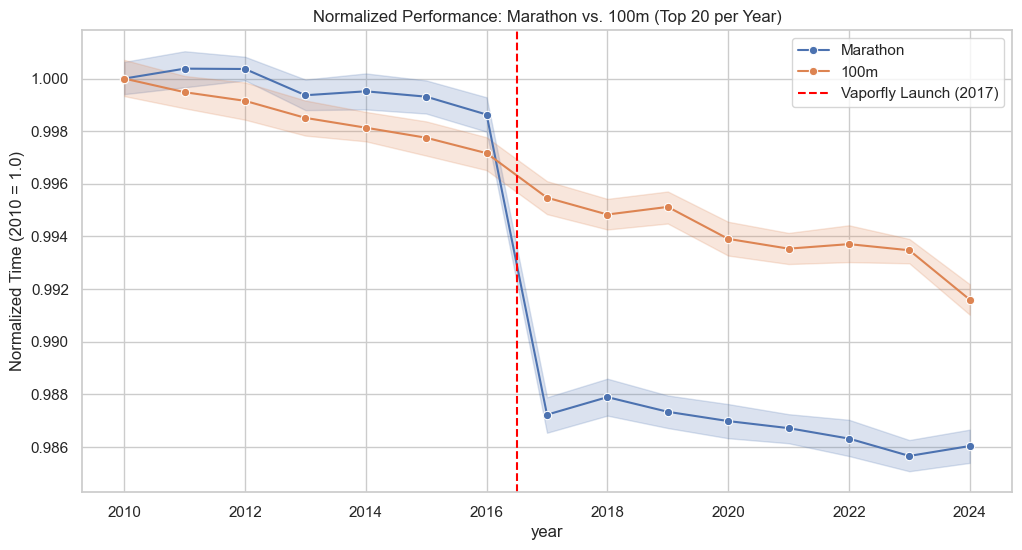

In [3]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_combined, x='year', y='norm_seconds', hue='event', marker='o')
plt.axvline(x=2016.5, color='red', linestyle='--', label='Vaporfly Launch (2017)')
plt.title("Normalized Performance: Marathon vs. 100m (Top 20 per Year)")
plt.ylabel("Normalized Time (2010 = 1.0)")
plt.legend()
plt.show()

## 3. Difference-in-Differences Model

In [4]:
df_did = df_combined.copy()
df_did['post_2017'] = (df_did['year'] >= 2017).astype(int)
df_did['is_marathon'] = (df_did['event'] == 'Marathon').astype(int)

model = smf.ols(formula="norm_seconds ~ is_marathon * post_2017", data=df_did).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           norm_seconds   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     1841.
Date:                Mon, 01 Jun 2026   Prob (F-statistic):          7.22e-301
Time:                        19:56:49   Log-Likelihood:                 2982.3
No. Observations:                 600   AIC:                            -5957.
Df Residuals:                     596   BIC:                            -5939.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.99